In [4]:
import os
from concurrent .futures .thread import ThreadPoolExecutor

import pandas as pd
from matplotlib import pyplot as plt
from sympy .printing .pretty .pretty_symbology import line_width

os .environ ['US_TIGER_SHAPEFILE_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/outagescraping/TIGER/tl_2020_us_county/tl_2020_us_county.shp'
os .environ ['CANADA_CENSUS_DIVISIONS_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/outagescraping/CanadaBoundaries/lcd_000b21a_e/lcd_000b21a_e.shp'
os .environ ['DATA_CACHE_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/research_summer_2025/data_cache/'


In [5]:
from research_spring_2025 import get_selected_regions
from research_spring_2025 import get_parent_cells
from research_spring_2025 import generate_h3_grid_from_gdf
from research_spring_2025 import get_cell_shape_from_id

counties =get_selected_regions ()
cells =generate_h3_grid_from_gdf (counties ,use_cached_file =True )
unique_parents =get_parent_cells (cells )


In [6]:
import numpy as np
import pandas as pd
import geopandas as gpd

import contextily as ctx

import matplotlib .pyplot as plt

from shapely .geometry import Polygon

from tqdm import tqdm

import h3
import h3pandas

from pyproj import Transformer


# Open Elevation Data


In [7]:
elevation_data_path ='/Users/aaronspaulding/data/Elevation_National_GDB/Elevation_National_GDB.gdb'
elevation_data_crs ='EPSG:4269'

BUFFER =0.01


In [9]:
from research_spring_2025 import process_parent_cell_elevation_data
from research_spring_2025 import process_parent_cell_elevation_data_wrapper


In [10]:
cells ['elevation']=np .nan


In [12]:
args_list =[
(parent_cell ,cells ,elevation_data_path ,elevation_data_crs ,BUFFER )
for parent_cell in unique_parents
]


In [14]:
from tqdm .contrib .concurrent import process_map
from tqdm .contrib .concurrent import thread_map

results =process_map (
process_parent_cell_elevation_data_wrapper ,
args_list ,
max_workers =24 ,
chunksize =1 ,
)

for group in results :
    for idx ,elev in group :
        cells .loc [idx ,'elevation']=elev


  0%|          | 0/1762 [00:00<?, ?it/s]

<Axes: >

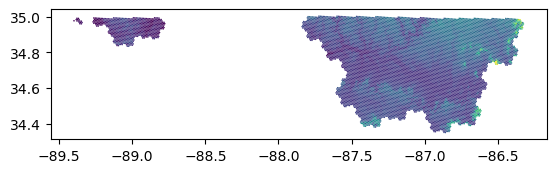

In [15]:
cells [0 :9_000 ].copy ().plot (
column ='elevation',
)


In [16]:
cells .drop (columns =['geometry','parents']).reset_index (drop =True ).to_feather ('/Users/aaronspaulding/Documents/PycharmProjects/research_summer_2025/data_cache/static_variables_elevation.feather')


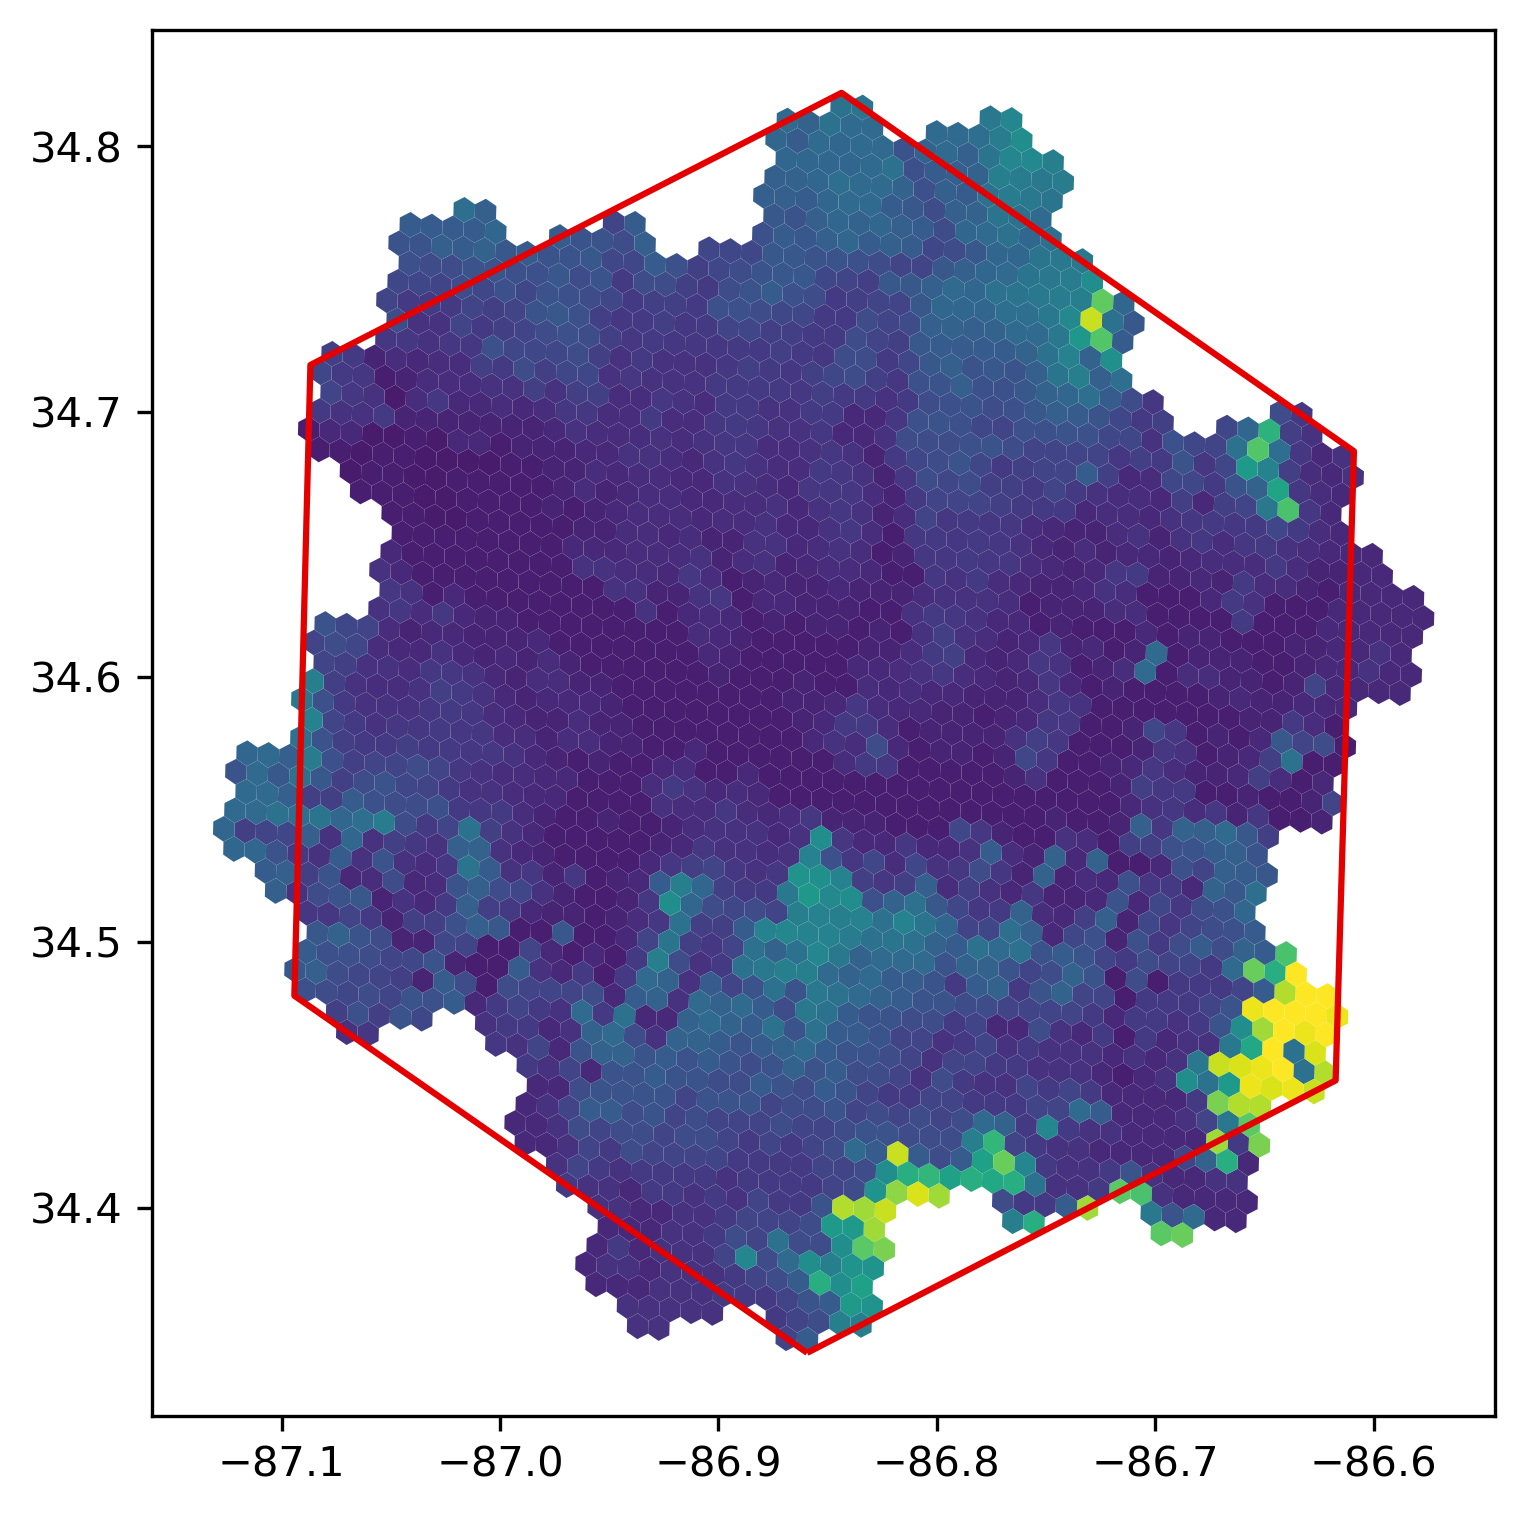

In [14]:
fig ,ax =plt .subplots (1 ,1 ,figsize =(6 ,6 ),dpi =300 )

cells [cells ['parents']==parent_h3_cell ].plot (ax =ax ,column ='elevation',linewidth =0.5 ,vmin =500 /3.2808399 ,vmax =1200 /3.2808399 )

plt .show ()


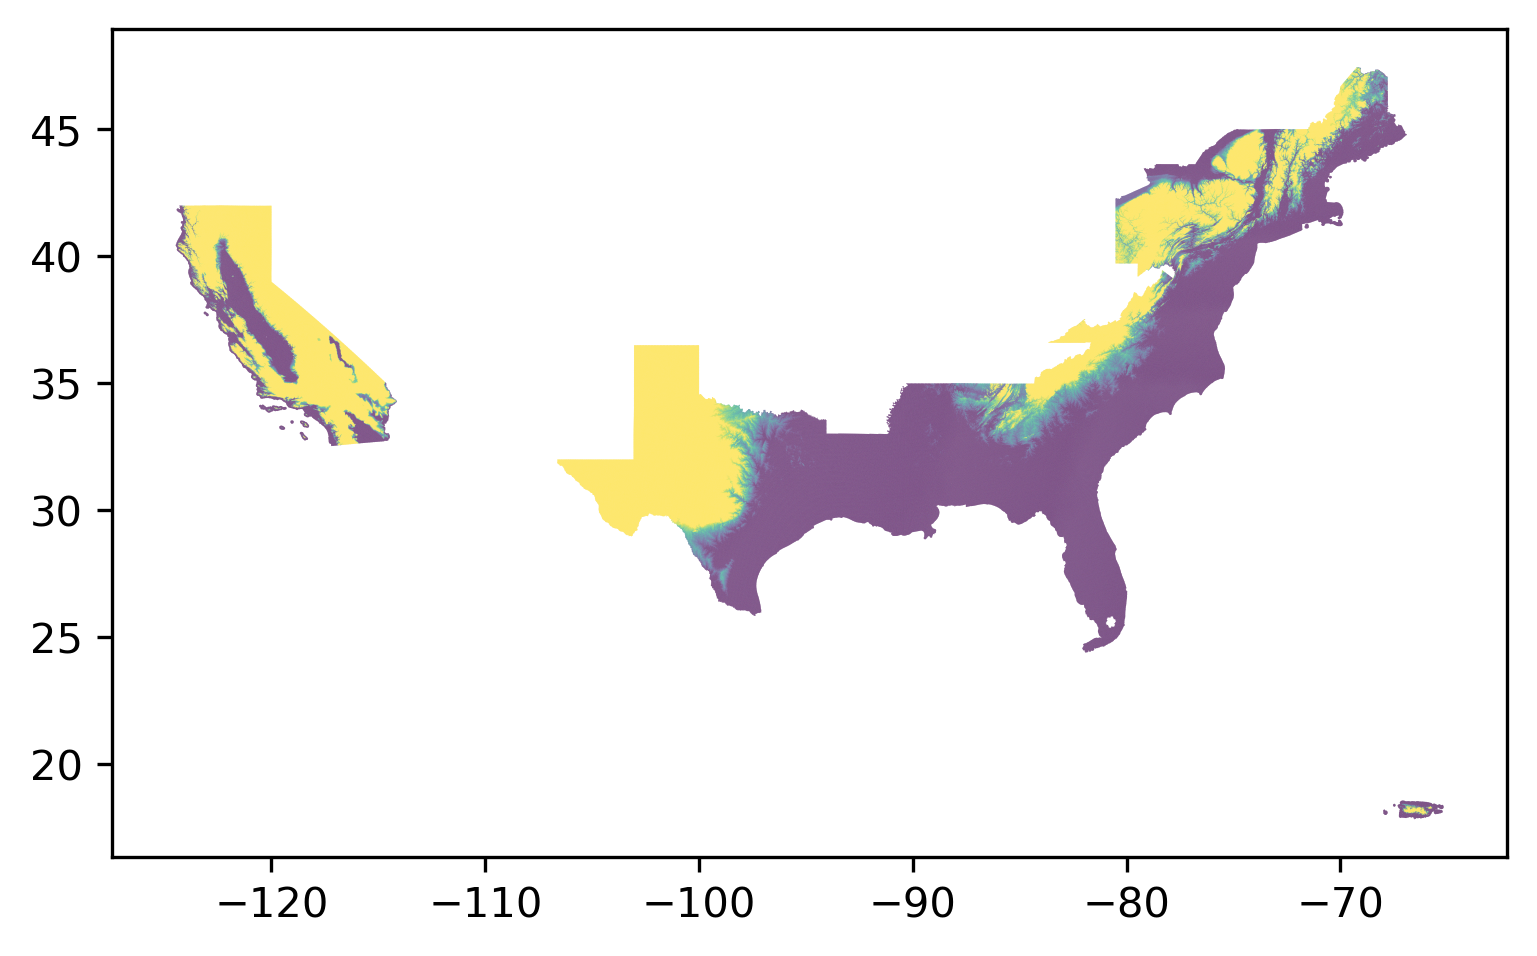

In [18]:
fig ,ax =plt .subplots (1 ,1 ,figsize =(6 ,6 ),dpi =300 )

cells .plot (ax =ax ,column ='elevation',linewidth =0.5 ,vmin =500 /3.2808399 ,vmax =1200 /3.2808399 )

plt .show ()


In [ ]:
fig ,ax =plt .subplots (1 ,1 ,figsize =(6 ,6 ),dpi =300 )

cells .plot (ax =ax ,column ='elevation')

plt .show ()
